# Predicción de *La Bola Negra* en los Premios Óscar

## Propósito del proyecto

En este proyecto desarrollo un modelo de aprendizaje automático para estimar las posibilidades de que *La Bola Negra*, representante de España, alcance la shortlist y consiga una nominación al Óscar a mejor película internacional.

Para ello analizo los resultados históricos de las películas presentadas por cada país y creo variables relacionadas con su trayectoria previa. Mi objetivo es convertir una noticia de actualidad en un análisis predictivo comprensible, reproducible y basado en datos.

## Carga de los datos

en este paso importo la hoja `peliculas` del archivo de libreoffice calc y compruebo sus primeras filas.

In [4]:
# importo la librería para trabajar con los datos
import pandas as pd

# cargo la hoja de películas
df = pd.read_excel(
    "modelo_oscar_internacional.ods",
    sheet_name="peliculas",
    engine="odf"
)

# muestro las primeras cinco filas
df.head()

,edicion,anio_ceremonia,pais,pelicula,shortlist,nominada,ganadora,nominaciones_pais_10a,victorias_pais_10a
0,84,2012,Albania,Amnesty,0,0,0,0,0
1,84,2012,Argentina,Aballay,0,0,0,2,1
2,84,2012,Austria,Breathing,0,0,0,2,1
3,84,2012,Belgium,Bullhead,1,1,0,0,0
4,84,2012,Bosnia and Herzegovina,Belvedere,0,0,0,1,1


## Exploración inicial

Compruebo el tamaño del conjunto de datos, el tipo de cada variable y la existencia de valores ausentes antes de comenzar el análisis.

In [5]:
# compruebo el número de filas y columnas
print("dimensiones:", df.shape)

# reviso el tipo de cada variable
print("\ntipos de datos:")
print(df.dtypes)

# cuento los valores ausentes de cada columna
print("\nvalores ausentes:")
print(df.isna().sum())

dimensiones: (1264, 9)

tipos de datos:
edicion                  int64
anio_ceremonia           int64
pais                       str
pelicula                   str
shortlist                int64
nominada                 int64
ganadora                 int64
nominaciones_pais_10a    int64
victorias_pais_10a       int64
dtype: object

valores ausentes:
edicion                  0
anio_ceremonia           0
pais                     0
pelicula                 0
shortlist                0
nominada                 0
ganadora                 0
nominaciones_pais_10a    0
victorias_pais_10a       0
dtype: int64


## Distribución de las variables objetivo

Analizo cuántas películas alcanzaron la shortlist y cuántas consiguieron la nominación. Esta comprobación permite detectar si existe un desequilibrio entre los resultados positivos y negativos.

In [6]:
# defino las dos variables que quiero predecir
objetivos = ["shortlist", "nominada"]

# calculo el número de casos y su porcentaje
for objetivo in objetivos:
    resultados = pd.DataFrame({
        "peliculas": df[objetivo].value_counts().sort_index(),
        "porcentaje": df[objetivo].value_counts(
            normalize=True
        ).sort_index().mul(100).round(2)
    })

    print(f"\ndistribución de {objetivo}:")
    display(resultados)


distribución de shortlist:


,peliculas,porcentaje
shortlist,,
0,1092,86.39
1,172,13.61



distribución de nominada:


,peliculas,porcentaje
nominada,,
0,1189,94.07
1,75,5.93


### Interpretación

El conjunto de datos presenta un desequilibrio claro entre las clases. Solo el 13,61 % de las películas alcanzó la shortlist y únicamente el 5,93 % consiguió una nominación.

Esto significa que los casos que quiero predecir son poco frecuentes. Por tanto, la exactitud por sí sola podría resultar engañosa: un modelo que predijera siempre un resultado negativo acertaría muchas veces sin identificar correctamente ninguna película con éxito.

Para evaluar los modelos tendré especialmente en cuenta métricas como la precisión, la sensibilidad, el F1-score y el área bajo la curva ROC.

In [7]:
# calculo la exactitud de predecir siempre la clase mayoritaria
for objetivo in objetivos:
    precision_referencia = (
        df[objetivo]
        .value_counts(normalize=True)
        .max()
    )

    print(
        f"{objetivo}: "
        f"{precision_referencia:.2%} de exactitud de referencia"
    )

shortlist: 86.39% de exactitud de referencia
nominada: 94.07% de exactitud de referencia


### Interpretación

Un modelo que predijera siempre que una película no tendrá éxito alcanzaría una exactitud del 86,39 % para la shortlist y del 94,07 % para la nominación.

Estos porcentajes, aunque parecen elevados, no representan un modelo útil: este enfoque no identificaría correctamente ninguna película que alcance alguno de los dos objetivos. Por tanto, los modelos que desarrolle deberán compararse con esta referencia y demostrar que son capaces de detectar los casos positivos.

## Comprobación de la coherencia de los datos

Verifico que las variables de resultado solo contengan valores binarios y que se respeten las relaciones lógicas entre shortlist, nominación y victoria. También compruebo que cada país tenga una única película por edición.

In [8]:
# compruebo que las variables de resultado sean binarias
for columna in ["shortlist", "nominada", "ganadora"]:
    valores_invalidos = (~df[columna].isin([0, 1])).sum()
    print(f"valores inválidos en {columna}: {valores_invalidos}")

# compruebo que toda nominada figure también en la shortlist
nominadas_sin_shortlist = (
    (df["nominada"] == 1) &
    (df["shortlist"] == 0)
).sum()

# compruebo que toda ganadora haya sido nominada
ganadoras_sin_nominacion = (
    (df["ganadora"] == 1) &
    (df["nominada"] == 0)
).sum()

# compruebo que las victorias históricas no superen las nominaciones
historial_incoherente = (
    df["victorias_pais_10a"] >
    df["nominaciones_pais_10a"]
).sum()

# compruebo que cada país tenga una sola película por edición
duplicados_edicion_pais = df.duplicated(
    subset=["edicion", "pais"]
).sum()

print(f"nominadas sin shortlist: {nominadas_sin_shortlist}")
print(f"ganadoras sin nominación: {ganadoras_sin_nominacion}")
print(f"historiales incoherentes: {historial_incoherente}")
print(f"duplicados por edición y país: {duplicados_edicion_pais}")

valores inválidos en shortlist: 0
valores inválidos en nominada: 0
valores inválidos en ganadora: 0
nominadas sin shortlist: 0
ganadoras sin nominación: 0
historiales incoherentes: 0
duplicados por edición y país: 0


### Interpretación

Las comprobaciones no han detectado valores inválidos, contradicciones ni registros duplicados. Todas las variables de resultado son binarias, las películas nominadas pertenecen a la shortlist y todas las ganadoras fueron previamente nominadas.

Además, las victorias históricas nunca superan a las nominaciones y cada país presenta una única película por edición. Por tanto, el conjunto de datos está preparado para continuar con el análisis.

## Influencia del historial del país

Comparo el número medio y mediano de nominaciones y victorias logradas por cada país durante los diez años anteriores. El objetivo es comprobar si la experiencia histórica está relacionada con alcanzar la shortlist o conseguir una nominación.

In [9]:
# selecciono las variables que resumen el historial del país
variables_historial = [
    "nominaciones_pais_10a",
    "victorias_pais_10a"
]

# comparo el historial según el resultado obtenido
for objetivo in objetivos:
    resumen = (
        df.groupby(objetivo)[variables_historial]
        .agg(["mean", "median"])
        .round(2)
    )

    print(f"\nhistorial según {objetivo}:")
    display(resumen)


historial según shortlist:


nominaciones_pais_10a        victorias_pais_10a       
                           mean median               mean median
shortlist                                                       
0                          0.45    0.0               0.09    0.0
1                          1.24    1.0               0.28    0.0


historial según nominada:


nominaciones_pais_10a        victorias_pais_10a       
                          mean median               mean median
nominada                                                       
0                         0.51    0.0               0.10    0.0
1                         1.40    1.0               0.32    0.0

### Interpretación

Las películas que alcanzaron la shortlist procedían de países con una media de 1,24 nominaciones durante la década anterior, frente a las 0,45 nominaciones de las películas que quedaron fuera.

La diferencia es todavía mayor entre las películas nominadas y las no nominadas: sus países acumulaban una media de 1,40 y 0,51 nominaciones previas, respectivamente.

Las victorias anteriores también son más frecuentes entre los casos exitosos, aunque su mediana es cero en todos los grupos. Esto indica que ganar es un acontecimiento poco habitual y que esta variable contiene menos información que el número de nominaciones.

Los resultados sugieren que la trayectoria reciente del país puede aportar capacidad predictiva, aunque esta asociación no demuestra por sí sola una relación causal.

## Visualización del historial del país

Represento la media de nominaciones y victorias obtenidas por los países durante los diez años anteriores, separando las películas según hayan alcanzado o no cada objetivo.

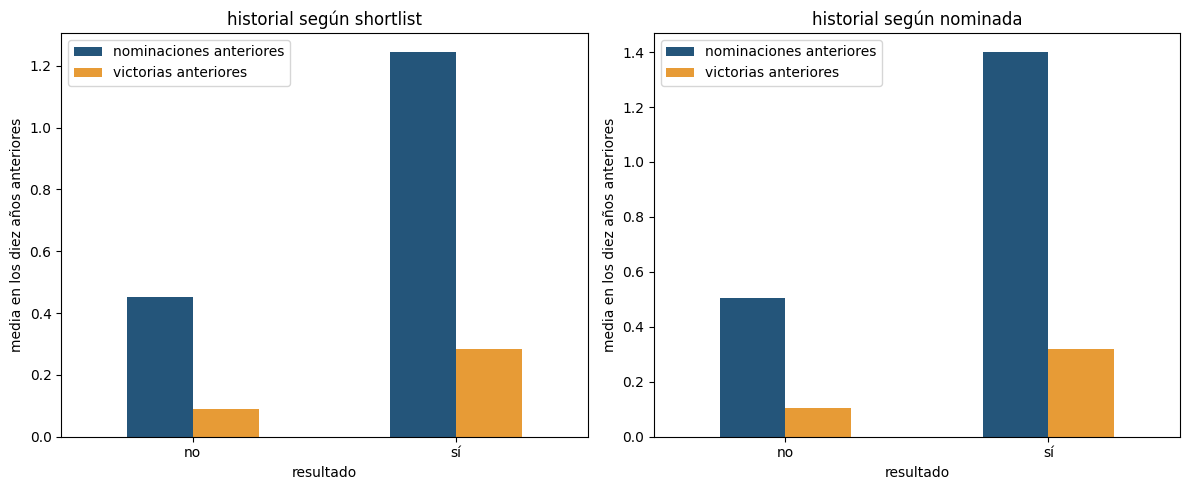

In [10]:
# importo la librería para crear gráficos
import matplotlib.pyplot as plt

# preparo los nombres que aparecerán en la leyenda
nombres_variables = {
    "nominaciones_pais_10a": "nominaciones anteriores",
    "victorias_pais_10a": "victorias anteriores"
}

# creo un gráfico para cada variable objetivo
fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

for eje, objetivo in zip(ejes, objetivos):
    medias = (
        df.groupby(objetivo)[variables_historial]
        .mean()
        .rename(columns=nombres_variables)
    )

    medias.plot(
        kind="bar",
        ax=eje,
        color=["#24557a", "#e79b36"]
    )

    eje.set_title(f"historial según {objetivo}")
    eje.set_xlabel("resultado")
    eje.set_ylabel("media en los diez años anteriores")
    eje.set_xticklabels(["no", "sí"], rotation=0)
    eje.legend(title="")

# ajusto la distribución de los elementos
plt.tight_layout()

# muestro el gráfico
plt.show()

### Interpretación

La visualización confirma que las películas procedentes de países con una trayectoria reciente más sólida obtienen mejores resultados.

La diferencia se aprecia especialmente en las nominaciones anteriores: los países con películas seleccionadas o nominadas presentan medias claramente superiores. Las victorias previas siguen la misma tendencia, pero sus valores son mucho menores porque ganar el premio es un suceso excepcional.

Estas diferencias respaldan la inclusión de ambas variables en el modelo predictivo, especialmente del número de nominaciones acumuladas durante los diez años anteriores.

## División temporal de los datos

Separo los datos según la edición de los premios. Utilizo las ediciones 84 a 95 para entrenar los modelos y reservo las ediciones 96 a 98 para evaluarlos.

No empleo una división aleatoria porque permitiría que películas recientes influyeran en la predicción de ediciones anteriores. La división temporal reproduce mejor el objetivo final: utilizar el pasado para predecir una edición futura.

In [11]:
# defino la primera edición que reservaré para la evaluación
edicion_corte = 96

# separo las ediciones antiguas para entrenar
df_entrenamiento = df[
    df["edicion"] < edicion_corte
].copy()

# separo las ediciones recientes para evaluar
df_prueba = df[
    df["edicion"] >= edicion_corte
].copy()

# compruebo el periodo y el tamaño de cada conjunto
print(
    "entrenamiento:",
    df_entrenamiento["edicion"].min(),
    "-",
    df_entrenamiento["edicion"].max(),
    df_entrenamiento.shape
)

print(
    "prueba:",
    df_prueba["edicion"].min(),
    "-",
    df_prueba["edicion"].max(),
    df_prueba.shape
)

# compruebo los casos positivos disponibles
for objetivo in objetivos:
    print(
        f"{objetivo}:",
        f"{df_entrenamiento[objetivo].sum()} positivos en entrenamiento,",
        f"{df_prueba[objetivo].sum()} positivos en prueba"
    )

entrenamiento: 84 - 95 (1005, 9)
prueba: 96 - 98 (259, 9)
shortlist: 127 positivos en entrenamiento, 45 positivos en prueba
nominada: 60 positivos en entrenamiento, 15 positivos en prueba


### Interpretación

El conjunto de entrenamiento contiene 1.005 películas de las ediciones 84 a 95, mientras que el conjunto de prueba reúne 259 películas de las ediciones 96 a 98.

Existen casos positivos en ambos grupos: 127 y 45 películas alcanzaron la shortlist, mientras que 60 y 15 consiguieron una nominación. Esto permite entrenar y evaluar los dos modelos.

La proporción de nominadas es muy similar en ambos periodos, alrededor del 6 %. Sin embargo, la shortlist representa el 12,64 % del entrenamiento y el 17,37 % de la prueba. Este aumento indica un cambio temporal que deberé tener en cuenta al interpretar las predicciones.

## Selección de las variables predictoras

Utilizo como variables predictoras el país de la película y sus nominaciones y victorias acumuladas durante los diez años anteriores.

Excluyo el nombre de la película porque funciona como un identificador, y también las variables `shortlist`, `nominada` y `ganadora`, ya que contienen los resultados que quiero predecir y provocarían una fuga de información. Tampoco incluyo simultáneamente la edición y el año porque representan prácticamente la misma información temporal.

In [12]:
# selecciono las variables que utilizaré para realizar las predicciones
variables_predictoras = [
    "pais",
    "nominaciones_pais_10a",
    "victorias_pais_10a"
]

# preparo las variables de entrenamiento y de prueba
x_entrenamiento = df_entrenamiento[variables_predictoras]
x_prueba = df_prueba[variables_predictoras]

# compruebo el resultado
print("dimensiones de entrenamiento:", x_entrenamiento.shape)
print("dimensiones de prueba:", x_prueba.shape)

display(x_entrenamiento.head())

dimensiones de entrenamiento: (1005, 3)
dimensiones de prueba: (259, 3)


,pais,nominaciones_pais_10a,victorias_pais_10a
0,Albania,0,0
1,Argentina,2,1
2,Austria,2,1
3,Belgium,0,0
4,Bosnia and Herzegovina,1,1


### Interpretación

El modelo utilizará tres variables predictoras: una variable categórica, correspondiente al país, y dos variables numéricas que resumen su trayectoria reciente.

Los conjuntos de entrenamiento y prueba conservan las 1.005 y 259 películas definidas en la división temporal. La variable `pais` necesitará transformarse a un formato numérico antes de entrenar el modelo.

## Preparación de las variables

Transformo el país mediante codificación *one-hot*, creando una columna binaria para cada país. También estandarizo las variables históricas para que sus diferentes escalas no condicionen el modelo.

La transformación se ajustará únicamente con el conjunto de entrenamiento para evitar que el modelo reciba información del periodo de prueba.

In [13]:
# importo las herramientas necesarias para transformar las variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# separo las variables según su tipo
variables_categoricas = ["pais"]
variables_numericas = [
    "nominaciones_pais_10a",
    "victorias_pais_10a"
]

# creo el proceso de transformación
preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            variables_categoricas
        ),
        (
            "numericas",
            StandardScaler(),
            variables_numericas
        )
    ]
)

print("preprocesador creado correctamente")

preprocesador creado correctamente


## Modelo de clasificación para la shortlist

Entreno una regresión logística porque ofrece una primera aproximación sencilla e interpretable. Utilizo pesos equilibrados para dar más importancia a las películas que alcanzaron la shortlist, ya que representan una minoría del conjunto de datos.

In [14]:
# importo el modelo y las herramientas para construir el proceso completo
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# selecciono el resultado que quiero predecir
y_entrenamiento_shortlist = df_entrenamiento["shortlist"]
y_prueba_shortlist = df_prueba["shortlist"]

# creo el proceso de transformación y entrenamiento
modelo_shortlist = Pipeline(
    steps=[
        ("preprocesador", clone(preprocesador)),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# entreno el modelo con las ediciones antiguas
modelo_shortlist.fit(
    x_entrenamiento,
    y_entrenamiento_shortlist
)

print("modelo de shortlist entrenado correctamente")

modelo de shortlist entrenado correctamente


## Evaluación del modelo de shortlist

Evalúo el modelo con las tres ediciones más recientes, que no participaron en el entrenamiento. Además de la exactitud, analizo la precisión, la sensibilidad, el F1-score, la exactitud equilibrada y el área bajo la curva ROC.

In [15]:
# importo las métricas para evaluar el modelo
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# genero las predicciones y sus probabilidades
prediccion_shortlist = modelo_shortlist.predict(x_prueba)
probabilidad_shortlist = modelo_shortlist.predict_proba(
    x_prueba
)[:, 1]

# calculo las métricas generales
print(
    "exactitud:",
    round(
        accuracy_score(
            y_prueba_shortlist,
            prediccion_shortlist
        ),
        3
    )
)

print(
    "exactitud equilibrada:",
    round(
        balanced_accuracy_score(
            y_prueba_shortlist,
            prediccion_shortlist
        ),
        3
    )
)

print(
    "roc auc:",
    round(
        roc_auc_score(
            y_prueba_shortlist,
            probabilidad_shortlist
        ),
        3
    )
)

# muestro las métricas de cada clase
print("\ninforme de clasificación:")
print(
    classification_report(
        y_prueba_shortlist,
        prediccion_shortlist,
        target_names=["no", "sí"],
        digits=3
    )
)

# creo una tabla con la matriz de confusión
matriz_shortlist = pd.DataFrame(
    confusion_matrix(
        y_prueba_shortlist,
        prediccion_shortlist
    ),
    index=["real: no", "real: sí"],
    columns=["predicción: no", "predicción: sí"]
)

display(matriz_shortlist)

exactitud: 0.676
exactitud equilibrada: 0.69
roc auc: 0.717

informe de clasificación:
              precision    recall  f1-score   support

          no      0.917     0.668     0.773       214
          sí      0.311     0.711     0.432        45

    accuracy                          0.676       259
   macro avg      0.614     0.690     0.603       259
weighted avg      0.811     0.676     0.714       259



,predicción: no,predicción: sí
real: no,143,71
real: sí,13,32


### Interpretación

El modelo obtiene un ROC AUC de 0,717, lo que indica una capacidad moderada para diferenciar entre las películas que alcanzan la shortlist y las que quedan fuera.

La sensibilidad de la clase positiva es del 71,1 %. Esto significa que identifica correctamente 32 de las 45 películas que realmente llegaron a la shortlist. Sin embargo, su precisión es del 31,1 %: de todas las películas que señala como posibles seleccionadas, aproximadamente una de cada tres lo consigue.

La exactitud general, del 67,6 %, es inferior a la del modelo de referencia. Esto se debe a que el modelo equilibrado intenta detectar los casos positivos en lugar de predecir siempre el resultado mayoritario. La exactitud equilibrada del 69 % refleja mejor este comportamiento.

Por tanto, el modelo resulta útil como herramienta de preselección, pero todavía produce demasiados falsos positivos para considerar sus predicciones concluyentes.

## Matriz de confusión del modelo de shortlist

Represento gráficamente los aciertos y errores del modelo para distinguir entre falsos positivos, falsos negativos y predicciones correctas.

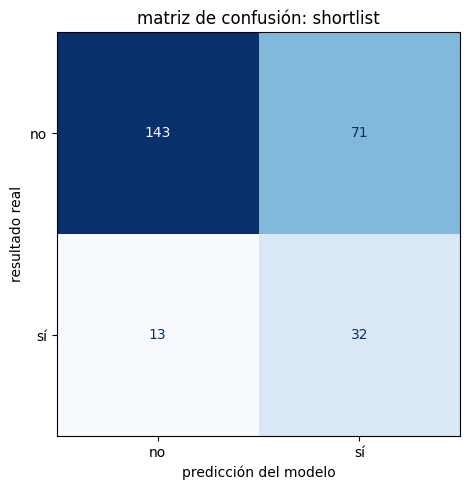

In [16]:
# importo la herramienta para visualizar la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

# creo el espacio para el gráfico
fig, eje = plt.subplots(figsize=(6, 5))

# represento los resultados del modelo
ConfusionMatrixDisplay.from_predictions(
    y_prueba_shortlist,
    prediccion_shortlist,
    display_labels=["no", "sí"],
    cmap="Blues",
    colorbar=False,
    ax=eje
)

# añado los títulos del gráfico
eje.set_title("matriz de confusión: shortlist")
eje.set_xlabel("predicción del modelo")
eje.set_ylabel("resultado real")

# ajusto y muestro el gráfico
plt.tight_layout()
plt.show()

### Interpretación

El modelo clasifica correctamente 143 películas que no alcanzaron la shortlist y 32 que sí lo hicieron. También deja escapar 13 películas seleccionadas y genera 71 falsos positivos.

El número relativamente bajo de falsos negativos confirma que el modelo consigue detectar buena parte de las candidaturas con éxito. Su principal limitación es la cantidad de películas que considera prometedoras pero que finalmente no alcanzan la shortlist.

Para el objetivo periodístico del proyecto, este comportamiento puede resultar útil como sistema de alerta o selección inicial, pero no como una predicción definitiva.

## Modelo de clasificación para la nominación

Entreno una segunda regresión logística para estimar si una película consigue la nominación. Mantengo los pesos equilibrados porque los casos positivos representan menos del 6 % del conjunto de datos.

In [17]:
# selecciono el segundo resultado que quiero predecir
y_entrenamiento_nominada = df_entrenamiento["nominada"]
y_prueba_nominada = df_prueba["nominada"]

# creo un proceso independiente para la nominación
modelo_nominada = Pipeline(
    steps=[
        ("preprocesador", clone(preprocesador)),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# entreno el modelo con las ediciones antiguas
modelo_nominada.fit(
    x_entrenamiento,
    y_entrenamiento_nominada
)

print("modelo de nominación entrenado correctamente")

modelo de nominación entrenado correctamente


## Evaluación del modelo de nominación

Evalúo el modelo con las ediciones 96 a 98 y utilizo las mismas métricas que en el modelo de shortlist para poder comparar sus resultados.

In [18]:
# genero las predicciones y sus probabilidades
prediccion_nominada = modelo_nominada.predict(x_prueba)
probabilidad_nominada = modelo_nominada.predict_proba(
    x_prueba
)[:, 1]

# calculo las métricas generales
print(
    "exactitud:",
    round(
        accuracy_score(
            y_prueba_nominada,
            prediccion_nominada
        ),
        3
    )
)

print(
    "exactitud equilibrada:",
    round(
        balanced_accuracy_score(
            y_prueba_nominada,
            prediccion_nominada
        ),
        3
    )
)

print(
    "roc auc:",
    round(
        roc_auc_score(
            y_prueba_nominada,
            probabilidad_nominada
        ),
        3
    )
)

# muestro las métricas de cada clase
print("\ninforme de clasificación:")
print(
    classification_report(
        y_prueba_nominada,
        prediccion_nominada,
        target_names=["no", "sí"],
        digits=3
    )
)

# creo una tabla con la matriz de confusión
matriz_nominada = pd.DataFrame(
    confusion_matrix(
        y_prueba_nominada,
        prediccion_nominada
    ),
    index=["real: no", "real: sí"],
    columns=["predicción: no", "predicción: sí"]
)

display(matriz_nominada)

exactitud: 0.676
exactitud equilibrada: 0.671
roc auc: 0.699

informe de clasificación:
              precision    recall  f1-score   support

          no      0.971     0.676     0.797       244
          sí      0.112     0.667     0.192        15

    accuracy                          0.676       259
   macro avg      0.541     0.671     0.495       259
weighted avg      0.921     0.676     0.762       259



,predicción: no,predicción: sí
real: no,165,79
real: sí,5,10


### Interpretación

El modelo de nominación obtiene un ROC AUC de 0,699, ligeramente inferior al alcanzado por el modelo de shortlist. Su capacidad para ordenar las candidaturas es moderada, pero está lejos de ofrecer una separación perfecta.

El modelo identifica correctamente 10 de las 15 películas nominadas, lo que representa una sensibilidad del 66,7 %. Sin embargo, genera 79 falsos positivos y su precisión para la clase positiva es únicamente del 11,2 %.

La exactitud general del 67,6 % vuelve a ser inferior a la referencia basada en predecir siempre el resultado mayoritario. La exactitud equilibrada, del 67,1 %, muestra que el modelo trata ambas clases de una forma más compensada.

Estos resultados indican que el historial del país aporta información, pero no es suficiente para predecir una nominación con alta fiabilidad. Será necesario incorporar variables relacionadas con festivales, premios previos y recepción de la película.

## Matriz de confusión del modelo de nominación

Visualizo los aciertos y errores del segundo modelo para observar con claridad su capacidad para detectar las películas nominadas.

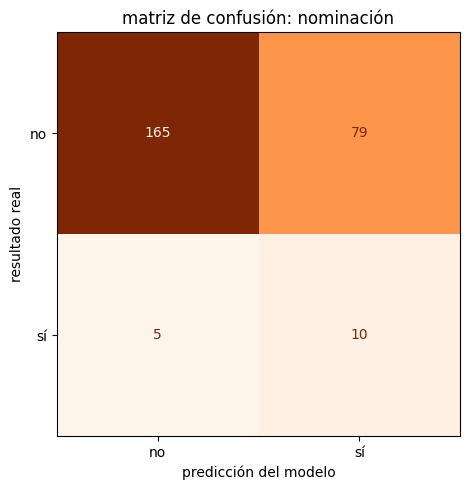

In [19]:
# creo el espacio para el segundo gráfico
fig, eje = plt.subplots(figsize=(6, 5))

# represento la matriz de confusión del modelo de nominación
ConfusionMatrixDisplay.from_predictions(
    y_prueba_nominada,
    prediccion_nominada,
    display_labels=["no", "sí"],
    cmap="Oranges",
    colorbar=False,
    ax=eje
)

# añado los títulos del gráfico
eje.set_title("matriz de confusión: nominación")
eje.set_xlabel("predicción del modelo")
eje.set_ylabel("resultado real")

# ajusto y muestro el gráfico
plt.tight_layout()
plt.show()

### Interpretación

La matriz de confusión muestra que el modelo acierta 165 resultados negativos y 10 nominaciones. Al mismo tiempo, no detecta 5 películas que sí fueron nominadas y clasifica incorrectamente 79 películas como posibles nominadas.

El modelo recupera dos tercios de las nominaciones reales, pero lo consigue a costa de producir numerosas falsas alarmas. Esto confirma que las variables históricas del país son relevantes, aunque insuficientes para realizar una predicción precisa por sí solas.

## Revisión de nuevas variables

Consulto el diccionario de variables del proyecto para identificar qué información adicional puede mejorar los modelos de shortlist y nominación.

In [20]:
# cargo el diccionario de variables del archivo
diccionario = pd.read_excel(
    "modelo_oscar_internacional.ods",
    sheet_name="diccionario_variables",
    engine="odf"
)

# configuro la visualización para leer mejor los textos
pd.set_option("display.max_colwidth", None)

# muestro el contenido completo del diccionario
display(diccionario)

,variable,modelo,tipo,definicion,fuente_prevista,momento_corte,estado
0,shortlist,Objetivo 1,0/1,La película entra en la shortlist,Academy Awards,Resultado,Disponible
1,nominada,Objetivo 2,0/1,La película obtiene la nominación final,Academy Awards,Resultado,Disponible
2,nominaciones_pais_10a,Ambos,Entero,Nominaciones logradas por el país en las diez ediciones anteriores,Base histórica,Antes de cada edición,Calculada
3,victorias_pais_10a,Ambos,Entero,Victorias logradas por el país en las diez ediciones anteriores,Base histórica,Antes de cada edición,Calculada
4,director_experiencia_oscar,Ambos,0/1,El director ya había llegado a una shortlist o nominación,Academy Awards y Wikidata,Antes de la shortlist,Por recopilar
5,seleccion_festival_a,Ambos,0/1,"Selección oficial en Cannes, Venecia o Berlín",Archivos de festivales,Antes de la shortlist,Por recopilar
6,premio_festival_a,Ambos,0/1,"Premio obtenido en Cannes, Venecia o Berlín",Archivos de festivales,Antes de la shortlist,Por recopilar
7,premio_publico_tiff,Ambos,0/1,La película ganó el People's Choice Award del TIFF,Toronto International Film Festival,Antes de la shortlist,Por recopilar
8,numero_festivales,Ambos,Entero,Número de festivales internacionales relevantes,Archivos de festivales,Antes de la shortlist,Por recopilar
9,coproduccion,Ambos,0/1,La película tiene más de un país productor,TMDb o Wikidata,Antes de la shortlist,Por recopilar


### Interpretación

El diccionario contiene 19 variables: dos objetivos, dos variables históricas ya calculadas y quince características pendientes de recopilar.

Las variables de festivales y la experiencia del director pueden mejorar ambos modelos. En cambio, la distribución en Estados Unidos, las nominaciones a otros premios y la recepción crítica corresponden especialmente al modelo de nominación, porque esa información aparece más adelante en la temporada.

Empezaré por `premio_publico_tiff`, ya que está directamente relacionada con la noticia que origina este proyecto. No obstante, tendré en cuenta que es un premio poco frecuente y que, por sí solo, podría aportar pocos casos positivos al entrenamiento.

## Premio del Público de Toronto

Creo una tabla con los ganadores históricos del People's Choice Award de TIFF y la cruzo con las películas presentadas al Óscar internacional. Antes de utilizar esta variable, compruebo cuántos casos positivos contiene realmente.

In [21]:
# importo las herramientas necesarias para normalizar los títulos
import re
import unicodedata

# creo la lista de ganadores del premio principal del público de tiff
ganadores_tiff = pd.DataFrame({
    "anio_tiff": list(range(2011, 2026)),
    "pelicula_tiff": [
        "Where Do We Go Now?",
        "Silver Linings Playbook",
        "12 Years a Slave",
        "The Imitation Game",
        "Room",
        "La La Land",
        "Three Billboards Outside Ebbing, Missouri",
        "Green Book",
        "Jojo Rabbit",
        "Nomadland",
        "Belfast",
        "The Fabelmans",
        "American Fiction",
        "The Life of Chuck",
        "Hamnet"
    ]
})

# relaciono cada festival con la edición posterior de los óscar
ganadores_tiff["edicion"] = ganadores_tiff["anio_tiff"] - 1927

# creo una función para facilitar la comparación entre títulos
def normalizar_titulo(texto):
    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    texto = re.sub(r"[^a-zA-Z0-9 ]", "", texto)
    return re.sub(r"\s+", " ", texto).strip().lower()

# normalizo los títulos de ambas tablas
datos_tiff = df.copy()
datos_tiff["titulo_normalizado"] = (
    datos_tiff["pelicula"].apply(normalizar_titulo)
)

ganadores_tiff["titulo_normalizado"] = (
    ganadores_tiff["pelicula_tiff"].apply(normalizar_titulo)
)

# busco ganadores de tiff dentro de las candidaturas internacionales
coincidencias_tiff = datos_tiff.merge(
    ganadores_tiff[
        ["edicion", "anio_tiff", "pelicula_tiff", "titulo_normalizado"]
    ],
    on=["edicion", "titulo_normalizado"],
    how="inner"
)

# muestro las coincidencias encontradas
print("coincidencias encontradas:", len(coincidencias_tiff))

display(
    coincidencias_tiff[
        [
            "edicion",
            "pais",
            "pelicula",
            "anio_tiff",
            "shortlist",
            "nominada"
        ]
    ]
)

coincidencias encontradas: 1


,edicion,pais,pelicula,anio_tiff,shortlist,nominada
0,84,Lebanon,Where Do We Go Now?,2011,0,0


### Interpretación

El cruce histórico solo encuentra una película presentada al Óscar internacional que hubiera ganado el People's Choice Award principal de TIFF: *Where Do We Go Now?*. Por tanto, esta variable contiene muy pocos casos para incorporarla al modelo.

Además, la comprobación de las fuentes oficiales muestra que el premio relevante de *La Bola Negra* no procede de TIFF. La película obtuvo el premio a mejor dirección, ex aequo, en el Festival de Cannes de 2026.

Por ello, descarto `premio_publico_tiff` y continúo el análisis con `premio_festival_a`, que recogerá los premios obtenidos en Cannes, Venecia o Berlín.

## Recopilación de premios del Festival de Cannes

Consulto el palmarés oficial de Cannes para identificar las películas que recibieron premios antes de competir por el Óscar internacional. Empiezo comprobando que puedo acceder correctamente al archivo del festival desde Python.

In [22]:
# importo la librería que utilizaré para consultar la página oficial
import requests

# defino una página histórica del palmarés de cannes
url_cannes = (
    "https://www.festival-cannes.com/"
    "retrospective/2011/palmares/"
)

# descargo el contenido de la página
respuesta_cannes = requests.get(
    url_cannes,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

# compruebo si la descarga se ha realizado correctamente
print("estado:", respuesta_cannes.status_code)
print("caracteres descargados:", len(respuesta_cannes.text))

estado: 200
caracteres descargados: 138331


In [23]:
# importo la herramienta para interpretar el contenido de la página
from bs4 import BeautifulSoup

# convierto el contenido descargado en una estructura navegable
sopa_cannes = BeautifulSoup(
    respuesta_cannes.text,
    "html.parser"
)

# localizo el primer premio principal
nodo_premio = sopa_cannes.find(
    string=lambda texto: (
        texto is not None and
        "Palme d'or" in texto
    )
)

# reviso la estructura html que contiene el premio
nodo_actual = nodo_premio

for nivel in range(6):
    nodo_actual = nodo_actual.parent

    print(
        nivel,
        nodo_actual.name,
        nodo_actual.get("class")
    )

0 span None
1 div ['lg:w-4/12', 'list_item__award', 'lg:text-right']
2 div ['list_item__content', 'flex', 'flex-col', 'justify-end', 'lg:flex-row', 'lg:justify-start', 'lg:items-center', 'lg:justify-content', 'flex-1']
3 div ['list_item', 'flex', 'justify-content', 'relative', 'py-1.25', 'highlight']
4 div ['list_container']
5 div ['w-full', 'lg:w-8/12']


In [24]:
# localizo el bloque completo de la palma de oro
bloque_premio = nodo_premio.find_parent(
    "div",
    class_="list_item"
)

# muestro sus textos en el orden en que aparecen
print(list(bloque_premio.stripped_strings))

['THE TREE OF LIFE', 'de Terrence MALICK', "Palme d'or"]


In [28]:
# preparo una lista para guardar los premios
premios_cannes_2011 = []

# recorro cada premio del contenedor
for bloque in contenedor_premios.find_all(
    "div",
    class_="list_item",
    recursive=False
):
    textos = list(bloque.stripped_strings)

    # ignoro los bloques que no contienen información suficiente
    if len(textos) < 2:
        continue

    # busco una película situada después de la palabra pour
    coincidencia_pour = next(
        (
            re.match(
                r"^pour\s+(.+)$",
                texto,
                flags=re.IGNORECASE
            )
            for texto in textos
            if re.match(
                r"^pour\s+(.+)$",
                texto,
                flags=re.IGNORECASE
            )
        ),
        None
    )

    # recupero el título de la película
    if coincidencia_pour:
        texto_pelicula = coincidencia_pour.group(1)
    else:
        texto_pelicula = textos[0]

    # guardo el año, la película y el tipo de premio
    premios_cannes_2011.append({
        "anio_festival": 2011,
        "pelicula_festival": texto_pelicula,
        "premio": textos[-1]
    })

# convierto los resultados en una tabla y elimino duplicados
premios_cannes_2011 = (
    pd.DataFrame(premios_cannes_2011)
    .drop_duplicates(
        subset=["pelicula_festival", "premio"]
    )
    .reset_index(drop=True)
)

display(premios_cannes_2011)

,anio_festival,pelicula_festival,premio
0,2011,THE TREE OF LIFE,Palme d'or
1,2011,LE GAMIN AU VÉLO,Grand Prix (Ex-Aequo)
2,2011,BIR ZAMANLAR ANADOLU’DA,Grand Prix (Ex-Aequo)
3,2011,DRIVE,Prix de la mise en scène
4,2011,HEARAT SHULAYIM,Prix du scénario
5,2011,POLISSE,Prix du Jury
6,2011,MELANCHOLIA,Prix d'interprétation féminine
7,2011,THE ARTIST,Prix d'interprétation masculine
8,2011,LA PIEL QUE HABITO,"Prix Vulcain de l'Artiste-Technicien, décerné par la C.S.T."


### Extracción automática del palmarés de Cannes

Automatizo la descarga del palmarés de la competición principal de Cannes para cada año del periodo analizado. El festival no se celebró en 2020, por lo que ese año no contiene premios.

In [29]:
# creo una función para extraer los premios de cada edición
def extraer_premios_cannes(anio):
    url = (
        "https://www.festival-cannes.com/"
        f"retrospective/{anio}/palmares/"
    )

    # descargo la página correspondiente al año
    respuesta = requests.get(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=30
    )

    # devuelvo una lista vacía si la página no está disponible
    if respuesta.status_code != 200:
        return []

    sopa = BeautifulSoup(
        respuesta.text,
        "html.parser"
    )

    # localizo la palma de oro de largometraje
    nodo_palma = sopa.find(
        string=lambda texto: (
            texto is not None and
            texto.replace("’", "'").strip().lower()
            == "palme d'or"
        )
    )

    # devuelvo una lista vacía si ese año no tuvo palmarés
    if nodo_palma is None:
        return []

    contenedor = nodo_palma.find_parent(
        "div",
        class_="list_container"
    )

    premios_anio = []

    # recorro los premios de la competición principal
    for bloque in contenedor.find_all(
        "div",
        class_="list_item",
        recursive=False
    ):
        textos = list(bloque.stripped_strings)

        if len(textos) < 2:
            continue

        coincidencia_pour = next(
            (
                re.match(
                    r"^pour\s+(.+)$",
                    texto,
                    flags=re.IGNORECASE
                )
                for texto in textos
                if re.match(
                    r"^pour\s+(.+)$",
                    texto,
                    flags=re.IGNORECASE
                )
            ),
            None
        )

        if coincidencia_pour:
            pelicula = coincidencia_pour.group(1)
        else:
            pelicula = textos[0]

        premios_anio.append({
            "anio_festival": anio,
            "pelicula_festival": pelicula,
            "premio": textos[-1]
        })

    return premios_anio


# extraigo los premios de todo el periodo
premios_cannes = []

for anio in range(2011, 2026):
    premios_anio = extraer_premios_cannes(anio)
    premios_cannes.extend(premios_anio)

    print(
        f"{anio}: {len(premios_anio)} películas premiadas"
    )

# creo la tabla definitiva y elimino duplicados
premios_cannes = (
    pd.DataFrame(premios_cannes)
    .drop_duplicates(
        subset=[
            "anio_festival",
            "pelicula_festival",
            "premio"
        ]
    )
    .reset_index(drop=True)
)

print("\ntotal de registros:", len(premios_cannes))

2011: 10 películas premiadas
2012: 8 películas premiadas
2013: 8 películas premiadas
2014: 9 películas premiadas
2015: 9 películas premiadas
2016: 9 películas premiadas
2017: 11 películas premiadas
2018: 10 películas premiadas
2019: 13 películas premiadas
2020: 0 películas premiadas
2021: 13 películas premiadas
2022: 14 películas premiadas
2023: 9 películas premiadas
2024: 9 películas premiadas
2025: 11 películas premiadas

total de registros: 141


### Cruce entre Cannes y los Premios Óscar

Relaciono cada edición de Cannes con la ceremonia de los Óscar celebrada al año siguiente. Normalizo los títulos y realizo una primera búsqueda de coincidencias exactas.

In [30]:
# relaciono el año de cannes con la edición posterior de los óscar
premios_cannes["edicion"] = (
    premios_cannes["anio_festival"] - 1927
)

# normalizo los títulos extraídos del festival
premios_cannes["titulo_normalizado"] = (
    premios_cannes["pelicula_festival"]
    .apply(normalizar_titulo)
)

# normalizo nuevamente los títulos de la base principal
datos_cannes = df.copy()

datos_cannes["titulo_normalizado"] = (
    datos_cannes["pelicula"]
    .apply(normalizar_titulo)
)

# cruzo las películas por edición y título
coincidencias_cannes = datos_cannes.merge(
    premios_cannes[
        [
            "edicion",
            "anio_festival",
            "pelicula_festival",
            "titulo_normalizado",
            "premio"
        ]
    ],
    on=["edicion", "titulo_normalizado"],
    how="inner"
)

# conservo una fila por película
coincidencias_cannes_unicas = (
    coincidencias_cannes
    .drop_duplicates(
        subset=["edicion", "pais", "pelicula"]
    )
    .reset_index(drop=True)
)

# muestro las coincidencias encontradas
print(
    "películas coincidentes:",
    len(coincidencias_cannes_unicas)
)

display(
    coincidencias_cannes_unicas[
        [
            "edicion",
            "pais",
            "pelicula",
            "anio_festival",
            "premio",
            "shortlist",
            "nominada"
        ]
    ]
)

películas coincidentes: 26


,edicion,pais,pelicula,anio_festival,premio,shortlist,nominada
0,85,Austria,Amour,2012,Palme d'or,1,1
1,86,Chad,GriGris,2013,"Prix Vulcain de l'Artiste-Technicien, décerné par la C.S.T.",0,0
2,86,Mexico,Heli,2013,Prix de la mise en scène,0,0
3,87,Canada,Mommy,2014,Prix du Jury (Ex-Aequo),0,0
4,87,Russia,Leviathan,2014,Prix du scénario,1,1
5,87,Turkey,Winter Sleep,2014,Palme d'or,0,0
6,89,Philippines,Ma' Rosa,2016,Prix d'interprétation féminine,0,0
7,90,Sweden,The Square,2017,Palme d'or,1,1
8,91,Italy,Dogman,2018,Prix d'interprétation masculine,0,0
9,91,Kazakhstan,Ayka,2018,Prix d'interprétation féminine,1,0


### Interpretación

La primera comparación encuentra 26 películas premiadas en Cannes que posteriormente representaron a sus países en los Óscar. Entre ellas, 16 alcanzaron la shortlist y 12 consiguieron la nominación.

Estos resultados provisionales muestran una asociación muy fuerte: el 61,5 % de las coincidencias llegó a la shortlist y el 46,2 % obtuvo la nominación, porcentajes muy superiores al 13,6 % y al 5,9 % del conjunto completo.

Sin embargo, todavía no puedo considerar definitiva la variable. Cannes publica numerosos títulos en su idioma original, mientras que la base de los Óscar utiliza títulos internacionales. Antes de incorporarla al modelo debo localizar y corregir esas diferencias para evitar falsos negativos.

### Búsqueda de títulos equivalentes

Comparo cada película premiada que no ha coincidido con las candidaturas de su misma edición. Utilizo una medida de similitud textual para localizar variaciones ortográficas o títulos parcialmente traducidos.

In [31]:
# importo la herramienta para medir la similitud entre textos
from difflib import SequenceMatcher

# creo una tabla con una fila por película premiada
premios_cannes_unicos = (
    premios_cannes
    .drop_duplicates(
        subset=["edicion", "titulo_normalizado"]
    )
    .copy()
)

# identifico las películas que ya han coincidido
claves_coincidentes = set(
    zip(
        coincidencias_cannes_unicas["edicion"],
        coincidencias_cannes_unicas["titulo_normalizado"]
    )
)

# conservo únicamente los títulos todavía no relacionados
premios_sin_coincidencia = premios_cannes_unicos[
    ~premios_cannes_unicos.apply(
        lambda fila: (
            fila["edicion"],
            fila["titulo_normalizado"]
        ) in claves_coincidentes,
        axis=1
    )
].copy()

# creo una función para buscar la candidatura más parecida
def buscar_titulo_parecido(fila):
    candidaturas = datos_cannes[
        datos_cannes["edicion"] == fila["edicion"]
    ]

    similitudes = candidaturas[
        "titulo_normalizado"
    ].apply(
        lambda titulo: SequenceMatcher(
            None,
            fila["titulo_normalizado"],
            titulo
        ).ratio()
    )

    mejor_indice = similitudes.idxmax()

    return pd.Series({
        "pais_candidato": datos_cannes.loc[
            mejor_indice,
            "pais"
        ],
        "pelicula_candidata": datos_cannes.loc[
            mejor_indice,
            "pelicula"
        ],
        "similitud": similitudes.loc[mejor_indice]
    })

# calculo la mejor coincidencia de cada película
posibles_coincidencias = premios_sin_coincidencia.join(
    premios_sin_coincidencia.apply(
        buscar_titulo_parecido,
        axis=1
    )
)

# selecciono las coincidencias que merece la pena revisar
revision_titulos = (
    posibles_coincidencias[
        posibles_coincidencias["similitud"] >= 0.35
    ]
    .sort_values(
        "similitud",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "títulos pendientes:",
    len(premios_sin_coincidencia)
)

print(
    "posibles equivalencias:",
    len(revision_titulos)
)

display(
    revision_titulos[
        [
            "anio_festival",
            "pelicula_festival",
            "pais_candidato",
            "pelicula_candidata",
            "similitud"
        ]
    ].head(40)
)

títulos pendientes: 102
posibles equivalencias: 101


,anio_festival,pelicula_festival,pais_candidato,pelicula_candidata,similitud
0,2018,CAPHARNAÜM,Lebanon,Capernaum,0.842105
1,2019,ATLANTIQUE,Senegal,Atlantics,0.736842
2,2017,120 BATTEMENTS PAR MINUTE,France,BPM (Beats per Minute),0.666667
3,2015,THE LOBSTER,Cambodia,The Last Reel,0.666667
4,2014,MAPS TO THE STARS,Slovakia,A Step into the Dark,0.648649
5,2013,LE PASSÉ,Iran,The Past,0.625000
6,2019,BACURAU,Kyrgyzstan,Aurora,0.615385
7,2024,THE SUBSTANCE,Paraguay,The Last Ones,0.615385
8,2024,ANORA,Peru,Yana-Wara,0.615385
9,2012,THE ANGELS’ SHARE,Indonesia,The Dancer,0.615385


### Revisión del emparejamiento

La similitud textual localiza algunas equivalencias reales, como *Capharnaüm* y *Capernaum*, pero también propone relaciones incorrectas. Por tanto, no aceptaré automáticamente estas coincidencias.

Además, el palmarés contiene premios honoríficos concedidos a personas y algunas películas compiten en los Óscar dos años después de pasar por Cannes. Corrijo ambos aspectos antes de revisar manualmente los títulos traducidos.

In [32]:
# elimino los premios honoríficos que no corresponden a películas
premios_cannes_limpios = premios_cannes[
    ~premios_cannes["premio"].str.contains(
        "honneur",
        case=False,
        na=False
    )
].copy()

# cruzo inicialmente las tablas utilizando solo el título
coincidencias_cannes = datos_cannes.merge(
    premios_cannes_limpios[
        [
            "anio_festival",
            "pelicula_festival",
            "titulo_normalizado",
            "premio"
        ]
    ],
    on="titulo_normalizado",
    how="inner"
)

# calculo el tiempo transcurrido entre el festival y la ceremonia
coincidencias_cannes["diferencia_anios"] = (
    coincidencias_cannes["anio_ceremonia"] -
    coincidencias_cannes["anio_festival"]
)

# conservo únicamente los premios anteriores al óscar
coincidencias_cannes = coincidencias_cannes[
    coincidencias_cannes["diferencia_anios"].isin([1, 2])
]

# conservo una fila por candidatura
coincidencias_cannes_unicas = (
    coincidencias_cannes
    .drop_duplicates(
        subset=["edicion", "pais", "pelicula"]
    )
    .reset_index(drop=True)
)

print(
    "películas coincidentes:",
    len(coincidencias_cannes_unicas)
)

display(
    coincidencias_cannes_unicas[
        [
            "edicion",
            "pais",
            "pelicula",
            "anio_festival",
            "diferencia_anios",
            "premio",
            "shortlist",
            "nominada"
        ]
    ]
)

películas coincidentes: 26


,edicion,pais,pelicula,anio_festival,diferencia_anios,premio,shortlist,nominada
0,85,Austria,Amour,2012,1,Palme d'or,1,1
1,86,Chad,GriGris,2013,1,"Prix Vulcain de l'Artiste-Technicien, décerné par la C.S.T.",0,0
2,86,Mexico,Heli,2013,1,Prix de la mise en scène,0,0
3,87,Canada,Mommy,2014,1,Prix du Jury (Ex-Aequo),0,0
4,87,Russia,Leviathan,2014,1,Prix du scénario,1,1
5,87,Turkey,Winter Sleep,2014,1,Palme d'or,0,0
6,89,Philippines,Ma' Rosa,2016,1,Prix d'interprétation féminine,0,0
7,90,Sweden,The Square,2017,1,Palme d'or,1,1
8,91,Italy,Dogman,2018,1,Prix d'interprétation masculine,0,0
9,91,Kazakhstan,Ayka,2018,1,Prix d'interprétation féminine,1,0


### Equivalencias entre títulos originales e internacionales

Registro manualmente las equivalencias confirmadas entre los títulos utilizados por Cannes y los títulos de la base de los Óscar. Mantengo esta tabla visible para que las decisiones de emparejamiento puedan revisarse.

In [33]:
# creo una tabla con las equivalencias de títulos confirmadas
equivalencias_titulos = pd.DataFrame([
    (2011, "BIR ZAMANLAR ANADOLU’DA", "Once Upon a Time in Anatolia"),
    (2011, "HEARAT SHULAYIM", "Footnote"),
    (2012, "DUPA DEALURI", "Beyond the Hills"),
    (2012, "JAGTEN", "The Hunt"),
    (2013, "LE PASSÉ", "The Past"),
    (2015, "SAUL FIA", "Son of Saul"),
    (2015, "NIE YINNIANG", "The Assassin"),
    (2016, "JUSTE LA FIN DU MONDE", "It's Only the End of the World"),
    (2016, "FORUSHANDE", "The Salesman"),
    (2017, "120 BATTEMENTS PAR MINUTE", "BPM (Beats per Minute)"),
    (2017, "NELYUBOV", "Loveless"),
    (2018, "MANBIKI KAZOKU", "Shoplifters"),
    (2018, "ZIMNA WOJNA", "Cold War"),
    (2018, "CAPHARNAÜM", "Capernaum"),
    (2019, "GISAENGCHUNG", "Parasite"),
    (2019, "ATLANTIQUE", "Atlantics"),
    (2019, "DOLOR Y GLORIA", "Pain and Glory"),
    (2021, "GHAHREMAN", "A Hero"),
    (2021, "HYTTI NRO 6", "Compartment No. 6"),
    (2021, "VERDENS VERSTE MENNESKE", "The Worst Person in the World"),
    (2022, "HEOJIL KYOLSHIM", "Decision to Leave"),
    (2022, "BOY FROM HEAVEN", "Cairo Conspiracy"),
    (2023, "KUOLLEET LEHDET", "Fallen Leaves"),
    (2023, "LA PASSION DE DODIN BOUFFANT", "The Taste of Things"),
    (2023, "KURU OTLAR ÜSTÜNE", "About Dry Grasses"),
    (2025, "UN SIMPLE ACCIDENT", "It Was Just an Accident"),
    (2025, "AFFEKSJONSVERDI", "Sentimental Value"),
    (2025, "O AGENTE SECRETO", "The Secret Agent"),
    (2025, "JEUNES MÈRES", "Young Mothers")
], columns=[
    "anio_festival",
    "titulo_cannes",
    "titulo_oscar"
])

# normalizo los títulos de la tabla de equivalencias
equivalencias_titulos["cannes_normalizado"] = (
    equivalencias_titulos["titulo_cannes"]
    .apply(normalizar_titulo)
)

# creo un diccionario para sustituir los títulos
diccionario_equivalencias = {
    (
        fila["anio_festival"],
        fila["cannes_normalizado"]
    ): fila["titulo_oscar"]
    for _, fila in equivalencias_titulos.iterrows()
}

# creo el título que utilizaré para buscar cada película
premios_cannes_limpios["titulo_busqueda"] = (
    premios_cannes_limpios.apply(
        lambda fila: diccionario_equivalencias.get(
            (
                fila["anio_festival"],
                fila["titulo_normalizado"]
            ),
            fila["pelicula_festival"]
        ),
        axis=1
    )
)

# normalizo el título de búsqueda
premios_cannes_limpios["titulo_busqueda_normalizado"] = (
    premios_cannes_limpios["titulo_busqueda"]
    .apply(normalizar_titulo)
)

# repito el cruce utilizando los títulos corregidos
coincidencias_cannes = datos_cannes.merge(
    premios_cannes_limpios[
        [
            "anio_festival",
            "pelicula_festival",
            "titulo_busqueda_normalizado",
            "premio"
        ]
    ],
    left_on="titulo_normalizado",
    right_on="titulo_busqueda_normalizado",
    how="inner"
)

# conservo únicamente premios obtenidos uno o dos años antes
coincidencias_cannes["diferencia_anios"] = (
    coincidencias_cannes["anio_ceremonia"] -
    coincidencias_cannes["anio_festival"]
)

coincidencias_cannes = coincidencias_cannes[
    coincidencias_cannes["diferencia_anios"].isin([1, 2])
]

# conservo una fila por película
coincidencias_cannes_unicas = (
    coincidencias_cannes
    .drop_duplicates(
        subset=["edicion", "pais", "pelicula"]
    )
    .reset_index(drop=True)
)

print(
    "películas coincidentes tras las equivalencias:",
    len(coincidencias_cannes_unicas)
)

print(
    "alcanzaron la shortlist:",
    coincidencias_cannes_unicas["shortlist"].sum()
)

print(
    "fueron nominadas:",
    coincidencias_cannes_unicas["nominada"].sum()
)

películas coincidentes tras las equivalencias: 54
alcanzaron la shortlist: 38
fueron nominadas: 26


### Interpretación

Tras corregir las diferencias entre títulos, identifico 54 películas premiadas en Cannes que posteriormente representaron a sus países en los Óscar.

De ellas, 38 alcanzaron la shortlist y 26 consiguieron la nominación. Esto equivale al 70,4 % y al 48,1 %, respectivamente, frente al 13,6 % y al 5,9 % observados en el conjunto completo.

La asociación es muy fuerte y convierte el premio de Cannes en una variable potencialmente relevante para los modelos. Aun así, estos resultados no implican causalidad: las películas premiadas también pueden contar con mayor calidad, visibilidad internacional, distribución o apoyo promocional.

## Creación de la variable `premio_cannes`

Asigno el valor 1 a las películas que habían recibido un premio en la competición principal de Cannes antes de la ceremonia de los Óscar. El resto de las películas recibe el valor 0.

In [34]:
# creo un conjunto con las candidaturas premiadas en cannes
claves_premiadas_cannes = set(
    zip(
        coincidencias_cannes_unicas["edicion"],
        coincidencias_cannes_unicas["pais"],
        coincidencias_cannes_unicas["pelicula"]
    )
)

# creo la variable binaria en la base principal
df["premio_cannes"] = df.apply(
    lambda fila: int(
        (
            fila["edicion"],
            fila["pais"],
            fila["pelicula"]
        ) in claves_premiadas_cannes
    ),
    axis=1
)

# compruebo cuántos valores tiene cada categoría
print(df["premio_cannes"].value_counts())

# compruebo su relación con los dos objetivos
display(
    pd.crosstab(
        df["premio_cannes"],
        [df["shortlist"], df["nominada"]],
        margins=True
    )
)

premio_cannes
0    1210
1      54
Name: count, dtype: int64


shortlist         0   1       All
nominada          0   0   1      
premio_cannes                    
0              1076  85  49  1210
1                16  12  26    54
All            1092  97  75  1264

### Interpretación

La variable identifica 54 películas premiadas en Cannes y asigna el valor 0 a las 1.210 restantes.

Entre las películas premiadas, 26 consiguieron la nominación, 12 alcanzaron la shortlist sin ser nominadas y 16 quedaron fuera de ambas fases. La tabla también mantiene la coherencia lógica: no existe ninguna película nominada que no hubiera pasado antes por la shortlist.

La variable se ha incorporado correctamente y ya puede utilizarse para comprobar si mejora el rendimiento predictivo de los modelos.

## Modelo de shortlist con el premio de Cannes

Añado `premio_cannes` al modelo inicial y mantengo la misma división temporal. De este modo puedo comprobar si la nueva variable mejora las predicciones sobre exactamente las mismas películas.

In [35]:
# actualizo los conjuntos para incluir la nueva variable
df_entrenamiento = df[
    df["edicion"] < edicion_corte
].copy()

df_prueba = df[
    df["edicion"] >= edicion_corte
].copy()

# añado el premio de cannes a las variables predictoras
variables_predictoras_cannes = [
    "pais",
    "nominaciones_pais_10a",
    "victorias_pais_10a",
    "premio_cannes"
]

variables_numericas_cannes = [
    "nominaciones_pais_10a",
    "victorias_pais_10a",
    "premio_cannes"
]

# preparo los nuevos conjuntos de variables
x_entrenamiento_cannes = df_entrenamiento[
    variables_predictoras_cannes
]

x_prueba_cannes = df_prueba[
    variables_predictoras_cannes
]

y_entrenamiento_shortlist = df_entrenamiento["shortlist"]
y_prueba_shortlist = df_prueba["shortlist"]

# creo el nuevo preprocesador
preprocesador_cannes = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            variables_categoricas
        ),
        (
            "numericas",
            StandardScaler(),
            variables_numericas_cannes
        )
    ]
)

# creo y entreno el modelo ampliado
modelo_shortlist_cannes = Pipeline(
    steps=[
        ("preprocesador", preprocesador_cannes),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

modelo_shortlist_cannes.fit(
    x_entrenamiento_cannes,
    y_entrenamiento_shortlist
)

print("modelo de shortlist con cannes entrenado correctamente")

modelo de shortlist con cannes entrenado correctamente


### Comparación de los modelos de shortlist

Comparo el modelo basado únicamente en el historial del país con la nueva versión que incorpora el premio de Cannes.

In [36]:
# importo las métricas adicionales para comparar los modelos
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)

# genero las predicciones del modelo ampliado
prediccion_shortlist_cannes = (
    modelo_shortlist_cannes.predict(
        x_prueba_cannes
    )
)

probabilidad_shortlist_cannes = (
    modelo_shortlist_cannes.predict_proba(
        x_prueba_cannes
    )[:, 1]
)

# creo una función para calcular las métricas principales
def calcular_metricas(
    valores_reales,
    predicciones,
    probabilidades
):
    return {
        "exactitud": accuracy_score(
            valores_reales,
            predicciones
        ),
        "exactitud_equilibrada": balanced_accuracy_score(
            valores_reales,
            predicciones
        ),
        "precision": precision_score(
            valores_reales,
            predicciones
        ),
        "sensibilidad": recall_score(
            valores_reales,
            predicciones
        ),
        "f1": f1_score(
            valores_reales,
            predicciones
        ),
        "roc_auc": roc_auc_score(
            valores_reales,
            probabilidades
        )
    }

# comparo el modelo inicial con el modelo ampliado
comparacion_shortlist = pd.DataFrame({
    "modelo inicial": calcular_metricas(
        y_prueba_shortlist,
        prediccion_shortlist,
        probabilidad_shortlist
    ),
    "modelo con cannes": calcular_metricas(
        y_prueba_shortlist,
        prediccion_shortlist_cannes,
        probabilidad_shortlist_cannes
    )
}).T.round(3)

display(comparacion_shortlist)

,exactitud,exactitud_equilibrada,precision,sensibilidad,f1,roc_auc
modelo inicial,0.676,0.690,0.311,0.711,0.432,0.717
modelo con cannes,0.726,0.676,0.338,0.600,0.432,0.757


### Interpretación

La incorporación del premio de Cannes mejora la exactitud del 67,6 % al 72,6 % y eleva el ROC AUC de 0,717 a 0,757. También aumenta ligeramente la precisión de las predicciones positivas, del 31,1 % al 33,8 %.

Sin embargo, la sensibilidad desciende del 71,1 % al 60 %. El nuevo modelo genera menos falsas alarmas, pero deja escapar un mayor número de películas que realmente alcanzan la shortlist. El F1-score permanece estable en 0,432.

En conjunto, el premio de Cannes mejora la capacidad del modelo para ordenar las candidaturas según su probabilidad de éxito, aunque el umbral de clasificación todavía deberá ajustarse según se prefiera detectar más candidaturas o reducir los falsos positivos.

## Modelo de nominación con el premio de Cannes

Entreno una nueva versión del modelo de nominación incorporando el premio de Cannes y comparo su rendimiento con el modelo inicial.

In [37]:
# actualizo las variables objetivo del modelo de nominación
y_entrenamiento_nominada = df_entrenamiento["nominada"]
y_prueba_nominada = df_prueba["nominada"]

# creo un modelo independiente con la nueva variable
modelo_nominada_cannes = Pipeline(
    steps=[
        (
            "preprocesador",
            clone(preprocesador_cannes)
        ),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# entreno el modelo ampliado
modelo_nominada_cannes.fit(
    x_entrenamiento_cannes,
    y_entrenamiento_nominada
)

# genero las nuevas predicciones
prediccion_nominada_cannes = (
    modelo_nominada_cannes.predict(
        x_prueba_cannes
    )
)

probabilidad_nominada_cannes = (
    modelo_nominada_cannes.predict_proba(
        x_prueba_cannes
    )[:, 1]
)

# comparo el modelo inicial con el modelo ampliado
comparacion_nominada = pd.DataFrame({
    "modelo inicial": calcular_metricas(
        y_prueba_nominada,
        prediccion_nominada,
        probabilidad_nominada
    ),
    "modelo con cannes": calcular_metricas(
        y_prueba_nominada,
        prediccion_nominada_cannes,
        probabilidad_nominada_cannes
    )
}).T.round(3)

display(comparacion_nominada)

,exactitud,exactitud_equilibrada,precision,sensibilidad,f1,roc_auc
modelo inicial,0.676,0.671,0.112,0.667,0.192,0.699
modelo con cannes,0.784,0.791,0.185,0.800,0.300,0.848


### Interpretación

El premio de Cannes mejora todas las métricas del modelo de nominación. La exactitud aumenta del 67,6 % al 78,4 %, mientras que la exactitud equilibrada pasa del 67,1 % al 79,1 %.

La sensibilidad alcanza el 80 %, por lo que el modelo identifica 12 de las 15 nominaciones del conjunto de prueba. La precisión también mejora, aunque continúa siendo reducida: solo el 18,5 % de las películas señaladas como nominadas obtiene realmente la candidatura.

El ROC AUC aumenta de 0,699 a 0,848, lo que indica una buena capacidad para ordenar las películas según su probabilidad de nominación. El F1-score también mejora de 0,192 a 0,300.

Estos resultados muestran que un premio en Cannes aporta una señal predictiva mucho más fuerte que el historial del país por sí solo. No obstante, la evaluación contiene únicamente 15 nominaciones reales, por lo que debo interpretar la mejora con cautela.

## Comparación visual de los modelos

Comparo la exactitud equilibrada, el F1-score y el ROC AUC de los modelos iniciales con sus versiones ampliadas mediante el premio de Cannes.

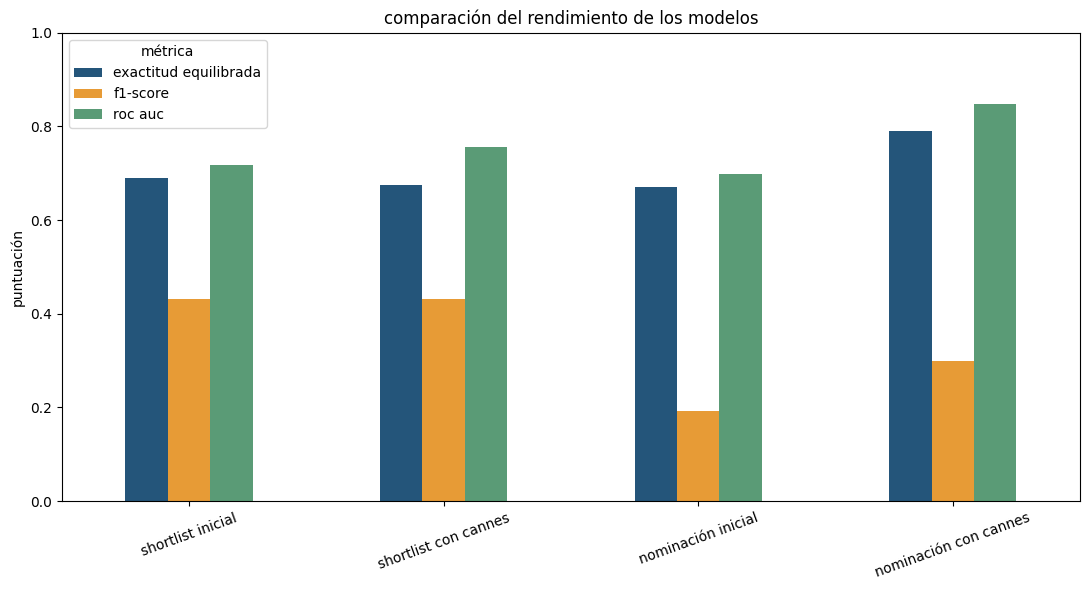

In [38]:
# reúno las métricas más informativas de los cuatro modelos
resumen_modelos = pd.DataFrame({
    "shortlist inicial": comparacion_shortlist.loc[
        "modelo inicial"
    ],
    "shortlist con cannes": comparacion_shortlist.loc[
        "modelo con cannes"
    ],
    "nominación inicial": comparacion_nominada.loc[
        "modelo inicial"
    ],
    "nominación con cannes": comparacion_nominada.loc[
        "modelo con cannes"
    ]
}).T[
    [
        "exactitud_equilibrada",
        "f1",
        "roc_auc"
    ]
]

# preparo los nombres que aparecerán en la leyenda
resumen_modelos = resumen_modelos.rename(
    columns={
        "exactitud_equilibrada": "exactitud equilibrada",
        "f1": "f1-score",
        "roc_auc": "roc auc"
    }
)

# creo el gráfico comparativo
eje = resumen_modelos.plot(
    kind="bar",
    figsize=(11, 6),
    color=["#24557a", "#e79b36", "#5a9b76"]
)

# añado los títulos y ajusto la escala
eje.set_title("comparación del rendimiento de los modelos")
eje.set_xlabel("")
eje.set_ylabel("puntuación")
eje.set_ylim(0, 1)
eje.tick_params(axis="x", rotation=20)
eje.legend(title="métrica")

# ajusto y muestro el gráfico
plt.tight_layout()
plt.show()

### Interpretación

La comparación visual confirma que el premio de Cannes aporta información predictiva, especialmente al modelo de nominación. En este caso mejoran claramente la exactitud equilibrada, el F1-score y el ROC AUC.

En el modelo de shortlist, Cannes mejora el ROC AUC, pero el F1-score permanece estable y la exactitud equilibrada disminuye ligeramente. Esto refleja el cambio observado anteriormente: el modelo ordena mejor las candidaturas, pero con el umbral actual detecta menos casos positivos.

El modelo de nominación con Cannes presenta el mejor equilibrio general de los cuatro modelos. Por ello, utilizaré esta nueva variable en las predicciones finales, manteniendo las métricas del modelo inicial como referencia.

## Preparación de *La Bola Negra*

Creo el registro que utilizarán los modelos para realizar la predicción de la edición 99. Calculo el historial de España empleando únicamente las diez ediciones anteriores y asigno el premio obtenido en Cannes.

In [39]:
# defino los datos básicos de la candidatura
edicion_prediccion = 99
pais_prediccion = "Spain"
pelicula_prediccion = "La Bola Negra"

# selecciono las diez ediciones anteriores de españa
historial_espana = df[
    (df["pais"] == pais_prediccion) &
    (df["edicion"] >= edicion_prediccion - 10) &
    (df["edicion"] < edicion_prediccion)
].copy()

# calculo las nominaciones y victorias recientes
nominaciones_espana_10a = int(
    historial_espana["nominada"].sum()
)

victorias_espana_10a = int(
    historial_espana["ganadora"].sum()
)

# creo el registro que utilizarán los modelos
la_bola_negra = pd.DataFrame([{
    "pais": pais_prediccion,
    "nominaciones_pais_10a": nominaciones_espana_10a,
    "victorias_pais_10a": victorias_espana_10a,
    "premio_cannes": 1
}])

# muestro el historial utilizado y el registro final
display(
    historial_espana[
        [
            "edicion",
            "pelicula",
            "shortlist",
            "nominada",
            "ganadora"
        ]
    ]
)

display(la_bola_negra)

,edicion,pelicula,shortlist,nominada,ganadora
446,89,Julieta,0,0,0
537,90,Summer 1993,0,0,0
624,91,Champions,0,0,0
715,92,Pain and Glory,1,1,0
808,93,The Endless Trench,0,0,0
900,94,The Good Boss,1,0,0
991,95,Alcarràs,0,0,0
1079,96,Society of the Snow,1,1,0
1166,97,Saturn Return,0,0,0
1252,98,Sirāt,1,1,0


,pais,nominaciones_pais_10a,victorias_pais_10a,premio_cannes
0,Spain,3,0,1


### Interpretación

España acumula tres nominaciones durante las diez ediciones anteriores: *Pain and Glory*, *Society of the Snow* y *Sirāt*. No consiguió ninguna victoria durante ese periodo.

Por tanto, *La Bola Negra* parte con un historial nacional superior al promedio del conjunto de datos y con una señal adicional especialmente relevante: el premio de dirección obtenido en Cannes.

El registro final contiene los valores `3`, `0` y `1` para las nominaciones previas, las victorias previas y el premio de Cannes, respectivamente.

## Evaluación de las probabilidades

Los modelos anteriores utilizan pesos equilibrados para detectar mejor los casos positivos. Sin embargo, esos pesos modifican artificialmente la proporción de las clases y pueden producir porcentajes demasiado altos.

Entreno versiones sin pesos y comparo su calibración mediante el Brier score. Cuanto menor sea esta métrica y más se aproxime la probabilidad media a la frecuencia real, más fiables serán los porcentajes.

In [40]:
# importo la métrica para evaluar la calidad de las probabilidades
from sklearn.metrics import brier_score_loss

# creo el modelo probabilístico de shortlist
modelo_shortlist_probabilidad = Pipeline(
    steps=[
        (
            "preprocesador",
            clone(preprocesador_cannes)
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# creo el modelo probabilístico de nominación
modelo_nominada_probabilidad = Pipeline(
    steps=[
        (
            "preprocesador",
            clone(preprocesador_cannes)
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# entreno ambos modelos sin pesos equilibrados
modelo_shortlist_probabilidad.fit(
    x_entrenamiento_cannes,
    y_entrenamiento_shortlist
)

modelo_nominada_probabilidad.fit(
    x_entrenamiento_cannes,
    y_entrenamiento_nominada
)

# calculo las probabilidades sobre el conjunto de prueba
probabilidad_shortlist_sin_pesos = (
    modelo_shortlist_probabilidad.predict_proba(
        x_prueba_cannes
    )[:, 1]
)

probabilidad_nominada_sin_pesos = (
    modelo_nominada_probabilidad.predict_proba(
        x_prueba_cannes
    )[:, 1]
)

# creo una función para resumir la calibración
def evaluar_probabilidades(
    valores_reales,
    probabilidades
):
    return {
        "brier": brier_score_loss(
            valores_reales,
            probabilidades
        ),
        "probabilidad_media": probabilidades.mean(),
        "frecuencia_real": valores_reales.mean(),
        "roc_auc": roc_auc_score(
            valores_reales,
            probabilidades
        )
    }

# comparo los modelos equilibrados y sin pesos
comparacion_probabilidades = pd.DataFrame({
    "shortlist equilibrado": evaluar_probabilidades(
        y_prueba_shortlist,
        probabilidad_shortlist_cannes
    ),
    "shortlist sin pesos": evaluar_probabilidades(
        y_prueba_shortlist,
        probabilidad_shortlist_sin_pesos
    ),
    "nominación equilibrado": evaluar_probabilidades(
        y_prueba_nominada,
        probabilidad_nominada_cannes
    ),
    "nominación sin pesos": evaluar_probabilidades(
        y_prueba_nominada,
        probabilidad_nominada_sin_pesos
    )
}).T.round(3)

display(comparacion_probabilidades)

,brier,probabilidad_media,frecuencia_real,roc_auc
shortlist equilibrado,0.164,0.369,0.174,0.757
shortlist sin pesos,0.116,0.130,0.174,0.760
nominación equilibrado,0.128,0.303,0.058,0.848
nominación sin pesos,0.040,0.065,0.058,0.857


### Interpretación

Los modelos sin pesos generan probabilidades mucho mejor calibradas. En la shortlist, el Brier score mejora de 0,164 a 0,116. En la nominación, la mejora es todavía mayor: pasa de 0,128 a 0,040.

La probabilidad media del modelo de nominación sin pesos es del 6,5 %, muy próxima a la frecuencia real del 5,8 %. El modelo equilibrado, en cambio, estima una media del 30,3 %, por lo que sobrevalora claramente las posibilidades.

Además, eliminar los pesos no reduce la capacidad de ordenación: el ROC AUC se mantiene prácticamente igual para la shortlist y aumenta ligeramente hasta 0,857 para la nominación.

Por tanto, utilizaré los modelos sin pesos para calcular los porcentajes finales de *La Bola Negra*. Conservaré los modelos equilibrados únicamente para analizar la detección de casos positivos.

## Predicción final para *La Bola Negra*

Después de evaluar la metodología con las tres ediciones reservadas, entreno los modelos probabilísticos definitivos con las 1.264 películas disponibles. Finalmente, calculo las posibilidades estimadas de alcanzar la shortlist y conseguir la nominación.

In [41]:
# preparo todas las películas históricas para el entrenamiento final
x_total = df[variables_predictoras_cannes]
y_total_shortlist = df["shortlist"]
y_total_nominada = df["nominada"]

# creo el modelo final de shortlist
modelo_final_shortlist = Pipeline(
    steps=[
        (
            "preprocesador",
            clone(preprocesador_cannes)
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# creo el modelo final de nominación
modelo_final_nominada = Pipeline(
    steps=[
        (
            "preprocesador",
            clone(preprocesador_cannes)
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# entreno los modelos con todo el historial disponible
modelo_final_shortlist.fit(
    x_total,
    y_total_shortlist
)

modelo_final_nominada.fit(
    x_total,
    y_total_nominada
)

# calculo las probabilidades de la bola negra
probabilidad_final_shortlist = (
    modelo_final_shortlist.predict_proba(
        la_bola_negra
    )[0, 1]
)

probabilidad_final_nominada = (
    modelo_final_nominada.predict_proba(
        la_bola_negra
    )[0, 1]
)

# creo una tabla con los resultados finales
prediccion_final = pd.DataFrame({
    "objetivo": [
        "alcanzar la shortlist",
        "conseguir la nominación"
    ],
    "probabilidad": [
        probabilidad_final_shortlist,
        probabilidad_final_nominada
    ]
})

prediccion_final["porcentaje"] = (
    prediccion_final["probabilidad"]
    .mul(100)
    .round(1)
    .astype(str)
    + " %"
)

display(
    prediccion_final[
        ["objetivo", "porcentaje"]
    ]
)

,objetivo,porcentaje
0,alcanzar la shortlist,74.7 %
1,conseguir la nominación,62.0 %


### Interpretación

El modelo estima que *La Bola Negra* tiene un 74,7 % de probabilidad de alcanzar la shortlist y un 62 % de conseguir la nominación final.

Ambos porcentajes se encuentran muy por encima de las frecuencias generales del conjunto de datos. La estimación está impulsada principalmente por el premio obtenido en Cannes y por las tres nominaciones logradas por España durante la última década.

La probabilidad de nominación es inferior a la de shortlist, lo que respeta el orden lógico del proceso de selección. Sin embargo, estos porcentajes no representan certezas ni probabilidades oficiales: son estimaciones condicionadas por las variables y los datos históricos utilizados.

Dado que los premios de Cannes y las nominaciones son acontecimientos poco frecuentes, calcularé también un intervalo de incertidumbre antes de utilizar estas cifras en el artículo.

## Intervalos de incertidumbre

Aplico un *bootstrap* por ediciones completas. En cada repetición selecciono quince ediciones con reemplazo, vuelvo a entrenar ambos modelos y recalculo las probabilidades de *La Bola Negra*.

Este procedimiento permite estimar cuánto dependen los resultados de las ediciones históricas utilizadas. Utilizo los percentiles 2,5 y 97,5 para construir un intervalo del 95 %.

In [42]:
# importo la librería para realizar el muestreo
import numpy as np

# preparo el generador aleatorio reproducible
generador = np.random.default_rng(42)

# identifico las ediciones históricas disponibles
ediciones_disponibles = (
    df["edicion"]
    .sort_values()
    .unique()
)

# preparo las listas que guardarán las probabilidades
probabilidades_bootstrap_shortlist = []
probabilidades_bootstrap_nominada = []

# defino el número de repeticiones
numero_repeticiones = 500

# repito el entrenamiento utilizando muestras de ediciones
for repeticion in range(numero_repeticiones):
    ediciones_muestra = generador.choice(
        ediciones_disponibles,
        size=len(ediciones_disponibles),
        replace=True
    )

    # reconstruyo la base con las ediciones seleccionadas
    muestra = pd.concat(
        [
            df[df["edicion"] == edicion]
            for edicion in ediciones_muestra
        ],
        ignore_index=True
    )

    x_muestra = muestra[variables_predictoras_cannes]
    y_muestra_shortlist = muestra["shortlist"]
    y_muestra_nominada = muestra["nominada"]

    # creo los dos modelos de la repetición
    modelo_bootstrap_shortlist = Pipeline(
        steps=[
            (
                "preprocesador",
                clone(preprocesador_cannes)
            ),
            (
                "modelo",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    )

    modelo_bootstrap_nominada = Pipeline(
        steps=[
            (
                "preprocesador",
                clone(preprocesador_cannes)
            ),
            (
                "modelo",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    )

    # entreno los modelos de la repetición
    modelo_bootstrap_shortlist.fit(
        x_muestra,
        y_muestra_shortlist
    )

    modelo_bootstrap_nominada.fit(
        x_muestra,
        y_muestra_nominada
    )

    # guardo las probabilidades obtenidas
    probabilidades_bootstrap_shortlist.append(
        modelo_bootstrap_shortlist.predict_proba(
            la_bola_negra
        )[0, 1]
    )

    probabilidades_bootstrap_nominada.append(
        modelo_bootstrap_nominada.predict_proba(
            la_bola_negra
        )[0, 1]
    )

# calculo los intervalos del 95 %
intervalos_prediccion = pd.DataFrame({
    "objetivo": [
        "alcanzar la shortlist",
        "conseguir la nominación"
    ],
    "estimacion": [
        probabilidad_final_shortlist,
        probabilidad_final_nominada
    ],
    "limite_inferior": [
        np.percentile(
            probabilidades_bootstrap_shortlist,
            2.5
        ),
        np.percentile(
            probabilidades_bootstrap_nominada,
            2.5
        )
    ],
    "limite_superior": [
        np.percentile(
            probabilidades_bootstrap_shortlist,
            97.5
        ),
        np.percentile(
            probabilidades_bootstrap_nominada,
            97.5
        )
    ]
})

# convierto los resultados a porcentajes
for columna in [
    "estimacion",
    "limite_inferior",
    "limite_superior"
]:
    intervalos_prediccion[columna] = (
        intervalos_prediccion[columna]
        .mul(100)
        .round(1)
    )

display(intervalos_prediccion)

,objetivo,estimacion,limite_inferior,limite_superior
0,alcanzar la shortlist,74.7,44.6,92.9
1,conseguir la nominación,62.0,31.8,82.2


### Interpretación

La estimación central mantiene un 74,7 % de probabilidad de alcanzar la shortlist y un 62 % de conseguir la nominación. Sin embargo, el *bootstrap* muestra una incertidumbre considerable.

El intervalo del 95 % para la shortlist se extiende aproximadamente desde el 44,6 % hasta el 92,9 %. Para la nominación, abarca desde el 31,8 % hasta el 82,2 %.

Esta amplitud indica que el resultado depende de forma importante de las ediciones históricas utilizadas. La señal favorable es consistente, pero la cantidad limitada de películas premiadas en Cannes impide realizar una estimación muy precisa.

En el artículo presentaré los porcentajes centrales acompañados de sus intervalos y explicaré que reflejan incertidumbre estadística, no un margen de error oficial de los Premios Óscar.

## Visualización de la predicción final

Represento las probabilidades estimadas junto con sus intervalos de incertidumbre. También incluyo la frecuencia histórica de cada resultado para mostrar cuánto se diferencia *La Bola Negra* de una candidatura promedio.

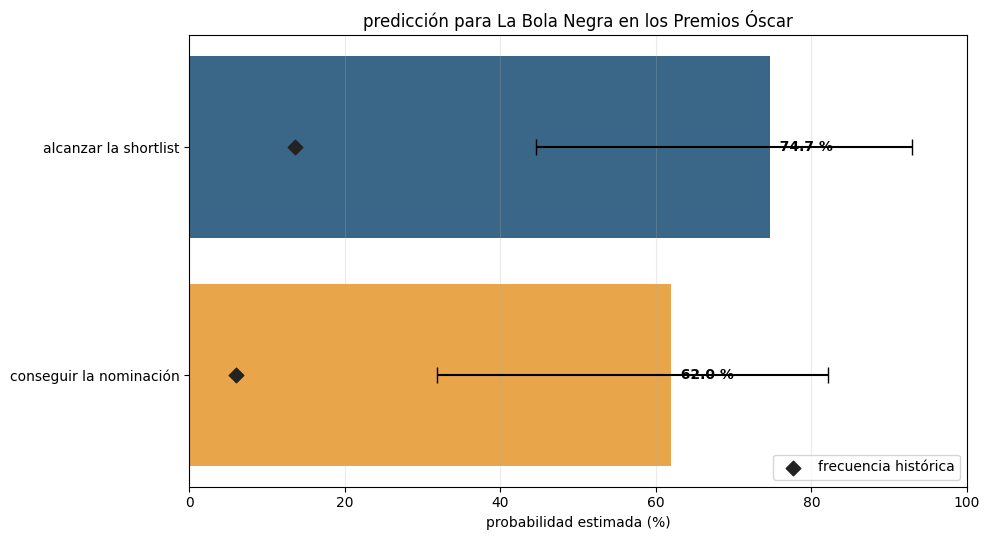

In [43]:
# preparo los datos del gráfico
etiquetas = [
    "alcanzar la shortlist",
    "conseguir la nominación"
]

estimaciones = (
    intervalos_prediccion["estimacion"]
    .to_numpy()
)

limites_inferiores = (
    intervalos_prediccion["limite_inferior"]
    .to_numpy()
)

limites_superiores = (
    intervalos_prediccion["limite_superior"]
    .to_numpy()
)

# calculo la distancia entre la estimación y cada límite
errores = np.array([
    estimaciones - limites_inferiores,
    limites_superiores - estimaciones
])

# calculo las frecuencias históricas de referencia
frecuencias_historicas = np.array([
    df["shortlist"].mean() * 100,
    df["nominada"].mean() * 100
])

# creo el gráfico
fig, eje = plt.subplots(figsize=(10, 5.5))

posiciones = np.arange(len(etiquetas))

eje.barh(
    posiciones,
    estimaciones,
    xerr=errores,
    capsize=6,
    color=["#24557a", "#e79b36"],
    alpha=0.9
)

# añado la frecuencia histórica de cada objetivo
eje.scatter(
    frecuencias_historicas,
    posiciones,
    color="#222222",
    marker="D",
    s=55,
    label="frecuencia histórica",
    zorder=3
)

# escribo el porcentaje central sobre cada barra
for posicion, estimacion in zip(
    posiciones,
    estimaciones
):
    eje.text(
        estimacion,
        posicion,
        f"  {estimacion:.1f} %",
        va="center",
        fontweight="bold"
    )

# configuro los títulos y la escala
eje.set_yticks(posiciones)
eje.set_yticklabels(etiquetas)
eje.invert_yaxis()
eje.set_xlim(0, 100)
eje.set_xlabel("probabilidad estimada (%)")
eje.set_title(
    "predicción para La Bola Negra en los Premios Óscar"
)
eje.grid(
    axis="x",
    alpha=0.25
)
eje.legend(loc="lower right")

# guardo y muestro el gráfico
plt.tight_layout()
plt.savefig(
    "prediccion_la_bola_negra.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interpretación

Los rombos negros representan la frecuencia histórica: el 13,6 % de las películas alcanzó la shortlist y el 5,9 % consiguió la nominación.

Las estimaciones para *La Bola Negra* se sitúan muy por encima de esas referencias. No obstante, las barras de error muestran que existe una incertidumbre considerable, especialmente porque los premios en Cannes son poco frecuentes dentro de la muestra.

La visualización resume la conclusión principal del análisis: *La Bola Negra* presenta un perfil históricamente favorable, pero el modelo no permite considerar asegurado ninguno de los dos resultados.

## Explicación de las predicciones

Descompongo la predicción de cada modelo para comprobar qué variables aumentan o reducen las posibilidades estimadas de *La Bola Negra*.

Las contribuciones se expresan en la escala interna de la regresión logística. Un valor positivo aumenta la estimación y uno negativo la reduce. Estos efectos describen el comportamiento del modelo, pero no demuestran relaciones causales.

In [44]:
# creo una función para explicar una predicción individual
def explicar_prediccion(modelo, registro):
    preprocesador_modelo = modelo.named_steps[
        "preprocesador"
    ]

    regresion = modelo.named_steps["modelo"]

    # transformo el registro con el mismo proceso del modelo
    valores_transformados = (
        preprocesador_modelo.transform(registro)
    )

    if hasattr(valores_transformados, "toarray"):
        valores_transformados = (
            valores_transformados.toarray()
        )

    valores_transformados = (
        valores_transformados.flatten()
    )

    # recupero los nombres y coeficientes de las variables
    nombres = (
        preprocesador_modelo
        .get_feature_names_out()
    )

    coeficientes = regresion.coef_[0]

    # calculo la aportación de cada variable
    explicacion = pd.DataFrame({
        "variable": nombres,
        "valor_transformado": valores_transformados,
        "coeficiente": coeficientes,
        "contribucion": (
            valores_transformados *
            coeficientes
        )
    })

    # conservo únicamente las variables activas
    explicacion = explicacion[
        explicacion["valor_transformado"] != 0
    ].copy()

    # simplifico los nombres para facilitar su lectura
    explicacion["variable"] = (
        explicacion["variable"]
        .str.replace(
            "categoricas__pais_",
            "pais: ",
            regex=False
        )
        .str.replace(
            "numericas__",
            "",
            regex=False
        )
    )

    # calculo el multiplicador sobre las probabilidades relativas
    explicacion["multiplicador_odds"] = np.exp(
        explicacion["contribucion"]
    )

    return (
        explicacion[
            [
                "variable",
                "contribucion",
                "multiplicador_odds"
            ]
        ]
        .sort_values(
            "contribucion",
            ascending=False
        )
        .round(3)
        .reset_index(drop=True)
    )

# explico la predicción de shortlist
print("contribuciones al modelo de shortlist:")
display(
    explicar_prediccion(
        modelo_final_shortlist,
        la_bola_negra
    )
)

# explico la predicción de nominación
print("contribuciones al modelo de nominación:")
display(
    explicar_prediccion(
        modelo_final_nominada,
        la_bola_negra
    )
)

contribuciones al modelo de shortlist:


,variable,contribucion,multiplicador_odds
0,premio_cannes,2.567,13.021
1,pais: Spain,0.496,1.642
2,nominaciones_pais_10a,0.252,1.286
3,victorias_pais_10a,-0.055,0.946


contribuciones al modelo de nominación:


,variable,contribucion,multiplicador_odds
0,premio_cannes,2.741,15.505
1,pais: Spain,0.812,2.252
2,nominaciones_pais_10a,0.199,1.220
3,victorias_pais_10a,-0.032,0.969


### Interpretación

El premio de Cannes es, con diferencia, la variable que más impulsa ambas predicciones. El efecto positivo es mayor en el modelo de nominación que en el de shortlist.

El hecho de representar a España también aumenta las estimaciones. A esto se suma el efecto favorable de las tres nominaciones obtenidas por el país durante la década anterior. La ausencia de victorias recientes ejerce una influencia negativa muy pequeña.

Los multiplicadores mostrados pertenecen a la escala interna del modelo y están calculados respecto al valor medio de las variables transformadas. Por tanto, no deben interpretarse literalmente como que Cannes multiplica por 13 o por 15 las probabilidades reales, ni como efectos causales.

La conclusión relevante es el orden de importancia: Cannes domina la predicción, seguido por el efecto asociado a España y por su historial reciente de nominaciones.

## Escenario sin el premio de Cannes

Creo un escenario contrafactual en el que mantengo España y su historial reciente, pero elimino el premio de Cannes. Esta comparación permite observar cuánto cambia la predicción del modelo al modificar únicamente esa variable.

In [45]:
# creo una copia de la candidatura sin el premio de cannes
la_bola_negra_sin_cannes = (
    la_bola_negra.copy()
)

la_bola_negra_sin_cannes[
    "premio_cannes"
] = 0

# calculo las probabilidades del escenario sin cannes
shortlist_sin_cannes = (
    modelo_final_shortlist.predict_proba(
        la_bola_negra_sin_cannes
    )[0, 1]
)

nominacion_sin_cannes = (
    modelo_final_nominada.predict_proba(
        la_bola_negra_sin_cannes
    )[0, 1]
)

# comparo ambos escenarios
comparacion_cannes = pd.DataFrame({
    "objetivo": [
        "alcanzar la shortlist",
        "conseguir la nominación"
    ],
    "con_cannes": [
        probabilidad_final_shortlist,
        probabilidad_final_nominada
    ],
    "sin_cannes": [
        shortlist_sin_cannes,
        nominacion_sin_cannes
    ]
})

# calculo la diferencia en puntos porcentuales
comparacion_cannes["diferencia_pp"] = (
    comparacion_cannes["con_cannes"] -
    comparacion_cannes["sin_cannes"]
) * 100

# convierto las probabilidades a porcentajes
for columna in [
    "con_cannes",
    "sin_cannes"
]:
    comparacion_cannes[columna] = (
        comparacion_cannes[columna]
        .mul(100)
        .round(1)
    )

comparacion_cannes["diferencia_pp"] = (
    comparacion_cannes["diferencia_pp"]
    .round(1)
)

display(comparacion_cannes)

,objetivo,con_cannes,sin_cannes,diferencia_pp
0,alcanzar la shortlist,74.7,16.8,57.9
1,conseguir la nominación,62.0,8.5,53.5


### Interpretación

Sin el premio de Cannes, el modelo estima un 16,8 % de probabilidad de shortlist y un 8,5 % de nominación. Estos valores se encuentran solo ligeramente por encima de las frecuencias históricas.

Al incorporar el premio, las estimaciones aumentan 57,9 puntos porcentuales para la shortlist y 53,5 puntos para la nominación. Por tanto, Cannes explica la mayor parte del perfil favorable de *La Bola Negra* dentro del modelo.

Esta comparación no demuestra que el premio cause directamente ese aumento. Refleja la fuerte asociación histórica entre recibir un galardón en Cannes y tener éxito posterior en los Óscar. También revela una limitación importante: la predicción depende en gran medida de una única variable que agrupa premios de distinta naturaleza.

## Impacto del premio de Cannes

Comparo las estimaciones de *La Bola Negra* con y sin el premio de Cannes y añado la frecuencia histórica de cada objetivo como referencia.

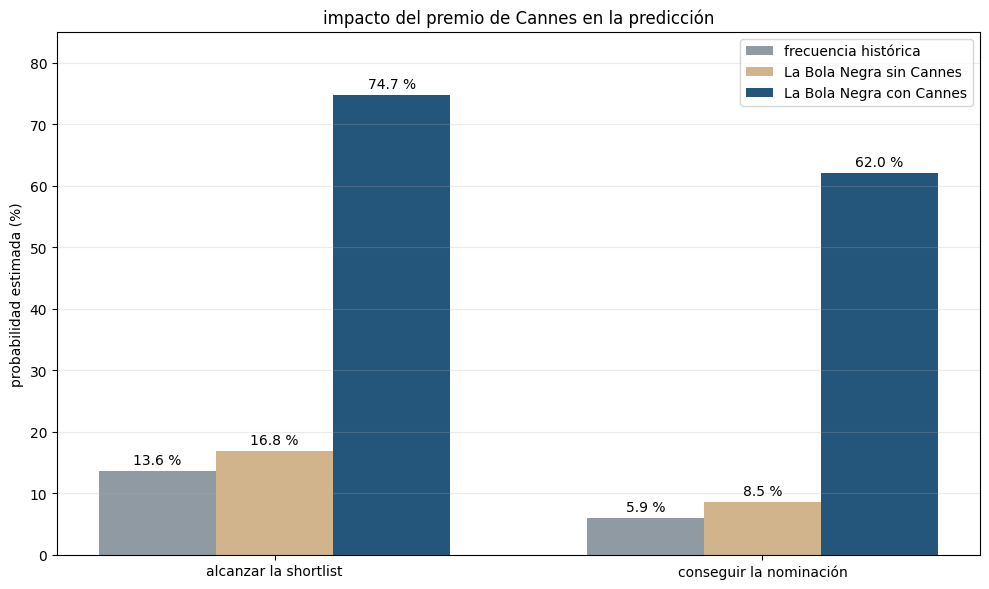

In [46]:
# preparo los valores de los tres escenarios
valores_historicos = np.array([
    df["shortlist"].mean() * 100,
    df["nominada"].mean() * 100
])

valores_sin_cannes = (
    comparacion_cannes["sin_cannes"]
    .to_numpy()
)

valores_con_cannes = (
    comparacion_cannes["con_cannes"]
    .to_numpy()
)

# defino la posición y el ancho de las barras
posiciones = np.arange(len(etiquetas))
ancho = 0.24

# creo el gráfico
fig, eje = plt.subplots(figsize=(10, 6))

barras_historicas = eje.bar(
    posiciones - ancho,
    valores_historicos,
    width=ancho,
    label="frecuencia histórica",
    color="#8f9aa3"
)

barras_sin_cannes = eje.bar(
    posiciones,
    valores_sin_cannes,
    width=ancho,
    label="La Bola Negra sin Cannes",
    color="#d2b48c"
)

barras_con_cannes = eje.bar(
    posiciones + ancho,
    valores_con_cannes,
    width=ancho,
    label="La Bola Negra con Cannes",
    color="#24557a"
)

# añado los porcentajes sobre las barras
for grupo_barras in [
    barras_historicas,
    barras_sin_cannes,
    barras_con_cannes
]:
    eje.bar_label(
        grupo_barras,
        fmt="%.1f %%",
        padding=3
    )

# configuro el aspecto del gráfico
eje.set_title(
    "impacto del premio de Cannes en la predicción"
)
eje.set_ylabel("probabilidad estimada (%)")
eje.set_xticks(posiciones)
eje.set_xticklabels(etiquetas)
eje.set_ylim(0, 85)
eje.grid(
    axis="y",
    alpha=0.25
)
eje.legend()

# guardo y muestro el gráfico
plt.tight_layout()
plt.savefig(
    "impacto_cannes_la_bola_negra.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interpretación

La comparación visual muestra que, sin el premio de Cannes, *La Bola Negra* se situaría cerca de una candidatura promedio, aunque ligeramente favorecida por el historial reciente de España.

El premio transforma por completo la predicción y eleva claramente ambas estimaciones. La diferencia es suficientemente grande como para constituir el principal hallazgo del análisis, pero también obliga a presentar el resultado con cautela: el modelo concentra gran parte de su decisión en una sola señal.

## Exportación de los resultados

Guardo la base enriquecida, las métricas, las equivalencias de títulos, las predicciones y los modelos finales. Estos archivos permiten revisar el proceso y reutilizar los resultados sin ejecutar nuevamente todo el cuaderno.

In [47]:
# importo las herramientas necesarias para guardar los archivos
from pathlib import Path
import joblib

# creo la carpeta que contendrá los resultados
carpeta_resultados = Path("resultados")
carpeta_resultados.mkdir(exist_ok=True)

# preparo la tabla completa de métricas
metricas_exportar = pd.concat(
    {
        "shortlist": comparacion_shortlist,
        "nominacion": comparacion_nominada
    },
    names=["objetivo", "modelo"]
).reset_index()

# preparo la tabla final de predicciones
predicciones_exportar = (
    intervalos_prediccion
    .merge(
        comparacion_cannes[
            [
                "objetivo",
                "sin_cannes",
                "diferencia_pp"
            ]
        ],
        on="objetivo",
        how="left"
    )
)

predicciones_exportar[
    "frecuencia_historica"
] = [
    round(df["shortlist"].mean() * 100, 1),
    round(df["nominada"].mean() * 100, 1)
]

# guardo los datos y resultados en formato csv
df.to_csv(
    carpeta_resultados / "datos_modelo_oscar.csv",
    index=False,
    encoding="utf-8-sig"
)

metricas_exportar.to_csv(
    carpeta_resultados / "metricas_modelos.csv",
    index=False,
    encoding="utf-8-sig"
)

predicciones_exportar.to_csv(
    carpeta_resultados / "prediccion_la_bola_negra.csv",
    index=False,
    encoding="utf-8-sig"
)

equivalencias_titulos.to_csv(
    carpeta_resultados / "equivalencias_titulos_cannes.csv",
    index=False,
    encoding="utf-8-sig"
)

premios_cannes_limpios.to_csv(
    carpeta_resultados / "premios_cannes.csv",
    index=False,
    encoding="utf-8-sig"
)

# guardo los dos modelos finales
joblib.dump(
    modelo_final_shortlist,
    carpeta_resultados / "modelo_final_shortlist.joblib"
)

joblib.dump(
    modelo_final_nominada,
    carpeta_resultados / "modelo_final_nominada.joblib"
)

# compruebo los archivos creados
for archivo in sorted(carpeta_resultados.iterdir()):
    print(archivo)

resultados\datos_modelo_oscar.csv
resultados\equivalencias_titulos_cannes.csv
resultados\metricas_modelos.csv
resultados\modelo_final_nominada.joblib
resultados\modelo_final_shortlist.joblib
resultados\prediccion_la_bola_negra.csv
resultados\premios_cannes.csv


## Conclusiones

El análisis estima que *La Bola Negra* tiene un 74,7 % de probabilidad de alcanzar la shortlist y un 62 % de conseguir la nominación al Óscar a mejor película internacional.

Los intervalos del 95 % son amplios: entre el 44,6 % y el 92,9 % para la shortlist, y entre el 31,8 % y el 82,2 % para la nominación. Por tanto, las estimaciones describen una candidatura fuerte, pero no un resultado asegurado.

El premio de dirección obtenido en Cannes es la variable que más impulsa ambas predicciones. Sin esa señal, las probabilidades descenderían al 16,8 % y al 8,5 %, respectivamente. El historial reciente de España, con tres nominaciones durante la última década, también contribuye positivamente.

El modelo de nominación que incorpora Cannes alcanza un ROC AUC de 0,848 en las tres ediciones reservadas para la evaluación. Aun así, el conjunto de prueba contiene únicamente quince nominaciones y la variable de Cannes agrupa premios de diferente naturaleza.

Estos resultados deben interpretarse como una estimación basada en patrones históricos, no como probabilidades oficiales ni como una garantía sobre las decisiones futuras de los votantes de la Academia.